In [2]:
print("hello")

hello


In [3]:
turso_db_url = "libsql://cairns-fuel-h-unter.aws-ap-northeast-1.turso.io"
with open("turso_token.txt") as file:
    turso_token = file.read().strip()

In [4]:
import libsql
conn = libsql.connect(database=turso_db_url, auth_token=turso_token)
result = conn.execute("""
SELECT * FROM Price_Records AS P
JOIN Sites AS S ON P.Site_ID = S.Site_ID
JOIN Fuel_Types AS F ON P.Fuel_ID = F.Fuel_ID
JOIN Brands AS B ON S.Brand_ID = B.Brand_ID
""")
saved_result = result.fetchall().copy()  # Save a copy of the results
conn.close()

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as ticker  
from matplotlib.lines import Line2D
import seaborn as sns
from datetime import datetime, date, timedelta

In [6]:
df = pd.DataFrame(saved_result)
column_name_to_saved_result_index = {
    "site_id": 0,
    "site_name": 6,
    "fuel_id": 1,
    "fuel_name": 12,
    "transaction_datetime": 2,
    "price": 3,
    "brand_id": 5,
    "brand_name": 14,
    "address": 7,
    "postcode": 8,
    "latitude": 9,
    "longitude": 10,
}
desired_columns = ["site_id", "site_name", "fuel_name", "transaction_datetime", "price", "brand_name", "address", "postcode", "latitude", "longitude"]
df = df[[column_name_to_saved_result_index[col] for col in desired_columns]]
df.columns = desired_columns
df['transaction_datetime'] = pd.to_datetime(df['transaction_datetime'])
df['transaction_date'] = df['transaction_datetime'].dt.date
df = df[df['price'] <= 9.0]
df

,site_id,site_name,fuel_name,transaction_datetime,price,brand_name,address,postcode,latitude,longitude,transaction_date
0,61401973,United Gordonvale,Unleaded,2025-09-04 14:55:04+10:00,1.749,United,68 Riverstone Road,4865,-17.099007,145.779894,2025-09-04
1,61401991,BP Edmonton,Unleaded,2025-10-03 14:29:56+10:00,1.749,BP,3/167 Bruce Hwy,4869,-17.017429,145.743907,2025-10-03
2,61402009,Ampol Mossman,Unleaded,2025-08-14 10:07:09+10:00,1.789,Ampol,67 Alchera,4873,-16.476177,145.374945,2025-08-14
3,61402015,Billabong Service Centre,Unleaded,2025-08-14 10:32:18+10:00,1.759,Independent,Captain Cook Hwy,4879,-16.771391,145.673257,2025-08-14
4,61402272,Mobil Brinsmead,Unleaded,2025-10-24 07:26:00+10:00,1.669,Mobil,101-115 Brinsmead Road,4870,-16.906246,145.710549,2025-10-24
...,...,...,...,...,...,...,...,...,...,...,...
7783,61402357,Ampol Cairns,Premium Diesel,2026-03-24 11:06:36+10:00,3.029,Ampol,60 Draper Street,4870,-16.935032,145.776411,2026-03-24
7784,61402393,Caltex Stratford,Premium Diesel,2026-03-24 10:41:57+10:00,3.099,Caltex,45 Arnold St,4870,-16.871103,145.739174,2026-03-24
7785,61402394,Caltex Bentley Park,Premium Diesel,2026-03-24 11:21:42+10:00,3.099,Caltex,28 Supply Rd,4869,-17.004223,145.743595,2026-03-24
7786,61402395,Caltex Portsmith,Premium Diesel,2026-03-24 10:40:55+10:00,3.099,Caltex,"104 Cook St, Portsmith QLD 4870, Australia",4870,-16.942830,145.769943,2026-03-24


In [7]:
# --- CONFIGURATION ---
def get_plot_data(plot_days, max_price, df, excluded_fuels=["Premium Diesel", "Premium Unleaded 95", "Premium Unleaded 98", "LPG"]):
    # Sort by time and filter outliers immediately
    df = df.sort_values('transaction_datetime')
    df = df[df['price'] <= max_price]

    # Define full simulation range and the specific plotting window
    start_date = df['transaction_date'].min()
    end_date = df['transaction_date'].max()
    plot_start_date = end_date - timedelta(days=plot_days)
    all_dates = pd.date_range(start=start_date, end=end_date)

    # Initialize state trackers
    current_prices = {fuel: {} for fuel in df['fuel_name'].unique()}
    plot_data = {} # Structure: { fuel: {'dates': [], 'prices': []} }
    transactions_by_date = df.groupby('transaction_date')

    # Single pass: Replay history and collect plot data simultaneously
    for current_datetime in all_dates:
        d = current_datetime.date()
        
        # 1. Update State: Apply today's price changes
        if d in transactions_by_date.groups:
            for _, row in transactions_by_date.get_group(d).iterrows():
                current_prices[row['fuel_name']][row['site_id']] = row['price']
                
        # 2. Collect Output: If date is within window, save the price lists
        if d >= plot_start_date:
            for fuel, sites in current_prices.items():
                if fuel in excluded_fuels:
                    continue
                    
                active_prices = list(sites.values())
                if active_prices:
                    if fuel not in plot_data:
                        plot_data[fuel] = {'dates': [], 'prices': []}
                    plot_data[fuel]['dates'].append(d)
                    plot_data[fuel]['prices'].append(active_prices)
    return plot_data

In [8]:
min_prices = df.groupby(['transaction_date', 'fuel_name'])['price'].transform('min')
cheapest_df = df[df['price'] == min_prices].copy()
cheapest_df = cheapest_df[cheapest_df['price'] < 4.0]
cheapest_df = cheapest_df.sort_values(by=['transaction_date', 'fuel_name'])
cheapest_df

,site_id,site_name,fuel_name,transaction_datetime,price,brand_name,address,postcode,latitude,longitude,transaction_date
7523,61470115,Thorpe Earthmoving,Diesel,2023-11-06 08:55:40+10:00,2.299,Independent,14 Perkins Street,4887,-17.386255,145.387214,2023-11-06
7535,61470115,Thorpe Earthmoving,Premium Unleaded 95,2023-11-06 08:55:40+10:00,2.139,Independent,14 Perkins Street,4887,-17.386255,145.387214,2023-11-06
7509,61470115,Thorpe Earthmoving,Unleaded,2023-11-06 08:55:40+10:00,2.139,Independent,14 Perkins Street,4887,-17.386255,145.387214,2023-11-06
98,61477839,Wondecla Service Station,Diesel,2025-04-16 14:06:27+10:00,1.959,Independent,1190 Longlands Gap Rd,4887,-17.409087,145.391515,2025-04-16
137,61477839,Wondecla Service Station,Premium Unleaded 95,2025-04-16 14:06:27+10:00,2.069,Independent,1190 Longlands Gap Rd,4887,-17.409087,145.391515,2025-04-16
...,...,...,...,...,...,...,...,...,...,...,...
7670,61470086,Mobil on Spence,Premium Unleaded 98,2026-03-24 08:23:50+10:00,2.665,Mobil,142A-146 Spence Street,4870,-16.929946,145.768766,2026-03-24
7673,61477011,Liberty Manoora,Premium Unleaded 98,2026-03-24 09:16:01+10:00,2.665,Liberty,31-35 Reservoir Rd,4870,-16.917089,145.735054,2026-03-24
7676,61477987,Mobil Sheridan Street,Premium Unleaded 98,2026-03-24 07:31:02+10:00,2.665,Mobil,237-241 Sheridan Street,4870,-16.911913,145.762875,2026-03-24
7617,61477011,Liberty Manoora,Unleaded,2026-03-24 09:16:01+10:00,2.435,Liberty,31-35 Reservoir Rd,4870,-16.917089,145.735054,2026-03-24


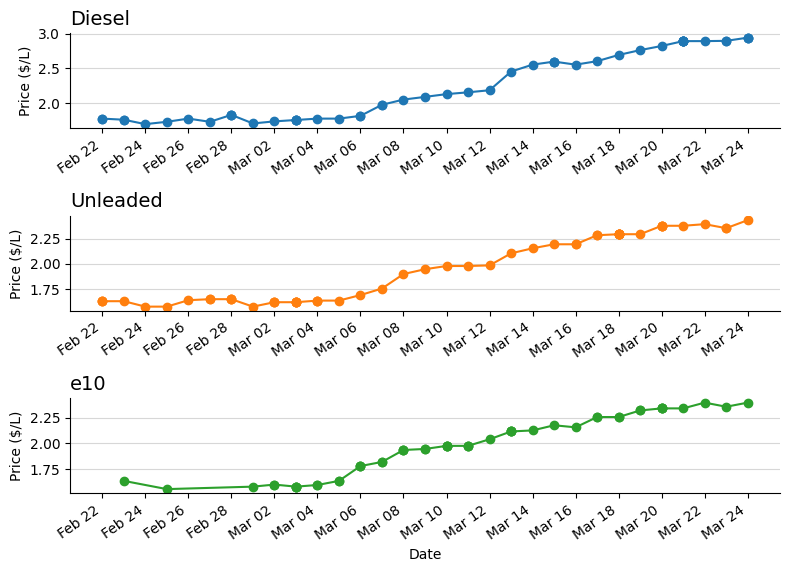

In [9]:

excluded_fuel_names = ["Premium Diesel", "Premium Unleaded 95", "Premium Unleaded 98"]

filtered_df = cheapest_df[
    (~cheapest_df['fuel_name'].isin(excluded_fuel_names)) &
    (cheapest_df['transaction_date'] >= date.today() - timedelta(days=30))
]

fuel_groups = list(filtered_df.groupby('fuel_name'))
n_plots = len(fuel_groups)
fig, ax = plt.subplots(
    n_plots,
    1,
    figsize=(8, 2 * n_plots),
    sharex=True
)

text_size = 10
text_size_large = 14
colours = plt.rcParams['axes.prop_cycle'].by_key()['color']
for i, (fuel_name, group) in enumerate(fuel_groups):
    colour = colours[i % len(colours)]
    ax[i].plot(
        group['transaction_date'],
        group['price'],
        marker='o',
        color=colour,
        label=fuel_name
    )

    ax[i].set_ylabel('Price ($/L)', fontsize=text_size)
    ax[i].set_title(fuel_name, fontsize=text_size_large, loc='left')

    ax[i].xaxis.set_major_locator(mdates.DayLocator(interval=2))
    ax[i].xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))

    ax[i].spines['top'].set_visible(False)
    ax[i].spines['right'].set_visible(False)
    ax[i].grid(True, axis='y', alpha=0.5)


# Only bottom plot gets x-label
ax[-1].set_xlabel('Date', fontsize=text_size)

for a in ax:
    a.tick_params(
        axis='x',
        which='both',
        labelbottom=True
    )
    plt.setp(a.get_xticklabels(), rotation=35, ha='right', fontsize=text_size)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig('plots/cheapest_fuel_30_days.svg', format='svg')
plt.show()

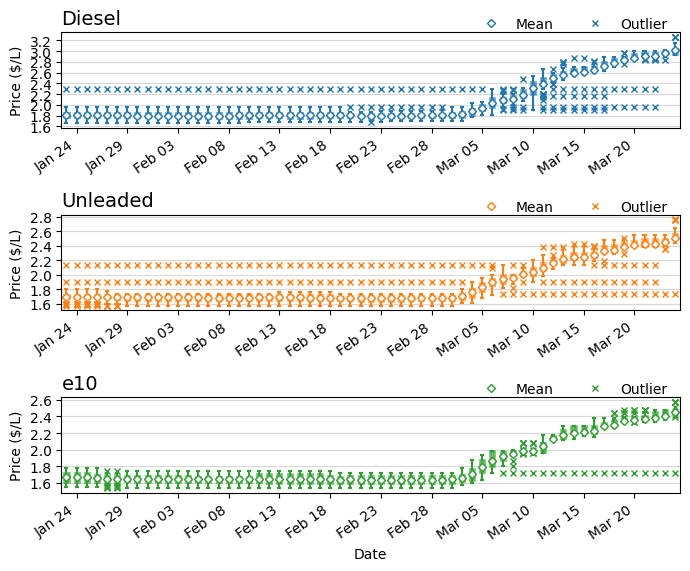

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as ticker
from matplotlib.lines import Line2D

# --- CONFIGURATION ---
is_boxplot = True       # Set to True to draw box plots
is_violinplot = False   # Set to True to draw violin plots (can be both True)

# --- HELPER FUNCTIONS ---

def draw_violin_plot(ax, prices, dates, colour):
    """Draws a violin plot on the given axes."""
    parts = ax.violinplot(
        prices,
        positions=dates,
        showmeans=True,
        showmedians=False,
        showextrema=True,
        widths=1.6
    )
    
    # Styling
    # Note: 'side' parameter is not standard in matplotlib.violinplot, so it is omitted.
    parts['cmeans'].set_color(colour)
    parts['cmins'].set_color(colour)
    parts['cmaxes'].set_color(colour)
    parts['cbars'].set_color(colour)
    
    for pc in parts['bodies']:
        pc.set_facecolor(colour)
        pc.set_alpha(0.6)

def draw_box_plot(ax, prices, dates, colour, text_size):
    """Draws a box plot on the given axes."""
    bp = ax.boxplot(
        prices,
        positions=dates,
        widths=0.4,
        patch_artist=True,
        showmeans=True,
        showfliers=True
    )
    
    # Styling Box Elements
    for box in bp['boxes']:
        box.set_facecolor(colour)
        box.set_edgecolor(colour)
        box.set_alpha(0.6)
        box.set_linewidth(2)
        
    for element in ['whiskers', 'caps']:
        plt.setp(bp[element], color=colour, linewidth=1.5)
        
    # Styling Lines and Markers
    plt.setp(bp['medians'], color=colour, linewidth=1.5)
    plt.setp(bp['means'], marker='D', markeredgecolor=colour, markerfacecolor='white', markersize=4)
    plt.setp(bp['fliers'], marker='x', markeredgecolor=colour, markersize=4)
    
    # Legend (Specific to Box Plot)
    legend_elements = [
        Line2D([0], [0], marker='D', color='w', label='Mean',
               markerfacecolor='white', markeredgecolor=colour, markersize=4),
        Line2D([0], [0], marker='x', color='w', label='Outlier',
               markeredgecolor=colour, markersize=4)
    ]
    
    ax.legend(
        handles=legend_elements,
        loc='lower right', 
        bbox_to_anchor=(1, 0.88), 
        frameon=False, 
        ncol=2,
        fontsize=text_size
    )


plot_data = get_plot_data(plot_days=60, max_price=5.0, df=df)
fuels_to_plot = sorted(plot_data.keys())
n_plots = len(fuels_to_plot)

fig, ax = plt.subplots(
    n_plots, 
    1, 
    figsize=(7, 2 * n_plots), 
    sharex=True
)
if n_plots == 1: ax = [ax]

colours = plt.rcParams['axes.prop_cycle'].by_key()['color']
text_size = 10
text_size_large = 14

for i, fuel_name in enumerate(fuels_to_plot):
    data = plot_data[fuel_name]
    colour = colours[i % len(colours)]
    numeric_dates = mdates.date2num(data['dates'])
    
    # --- CONDITIONAL PLOTTING ---
    if is_violinplot:
        draw_violin_plot(ax[i], data['prices'], numeric_dates, colour)
        
    if is_boxplot:
        draw_box_plot(ax[i], data['prices'], numeric_dates, colour, text_size)
    # ----------------------------

    # Standard Axis Formatting
    ax[i].set_ylabel('Price ($/L)', fontsize=text_size)
    ax[i].set_title(fuel_name, fontsize=text_size_large, loc='left')

    ax[i].yaxis.set_major_locator(ticker.MultipleLocator(0.2))
    ax[i].xaxis.set_major_locator(mdates.DayLocator(interval=5))
    ax[i].xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
    
    # Grid and Spines
    ax[i].grid(True, axis='y', alpha=0.5, zorder=-1)
    
    # Note: If you want spines visible, do not set them to False.
    # ax[i].spines['top'].set_visible(False) 
    # ax[i].spines['right'].set_visible(False)
    # ax[i].spines['left'].set_visible(False)

ax[-1].set_xlabel('Date', fontsize=text_size)

for a in ax:
    a.tick_params(axis='x', which='both', labelbottom=True)
    plt.setp(a.get_xticklabels(), rotation=35, ha='right', fontsize=text_size)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

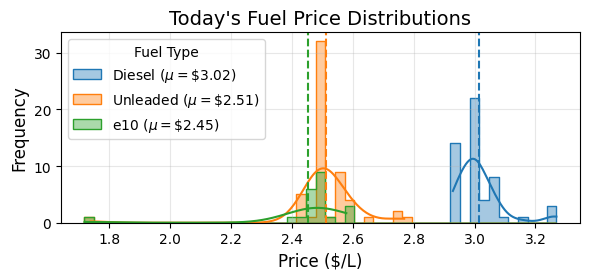

In [13]:
# generate the distribution of all fuel prices for today. Do this for each fuel type
todays_plot_data = get_plot_data(plot_days=0, max_price=5.0, df=df)
fuels_to_plot = sorted(todays_plot_data.keys())

# 1. Gather all prices into one list to find global min/max
all_prices = []
for fuel in fuels_to_plot:
    all_prices.extend(todays_plot_data[fuel]['prices'][0])

# 2. Define shared bin edges
# We use linspace to ensure every histogram uses the exact same 'buckets'
global_min = min(all_prices)
global_max = max(all_prices)
shared_bins = np.linspace(global_min, global_max, 50) 

plt.figure(figsize=(6, 3))
colours = plt.rcParams['axes.prop_cycle'].by_key()['color']

# 3. Overlay histograms using the shared_bins
for fuel in fuels_to_plot:
    prices = todays_plot_data[fuel]['prices'][0]
    colour = colours[fuels_to_plot.index(fuel) % len(colours)]
    
    # Calculate the mean price FIRST so we can add it to the legend label
    mean_price = np.mean(prices)
    
    # Create the label using an f-string and Matplotlib's math text for mu
    # Formatting to 2 decimal places (:.2f) since it's a price
    legend_label = rf"{fuel} ($\mu=\${mean_price:.2f}$)"
    
    sns.histplot(
        prices, 
        bins=shared_bins,  
        kde=True, 
        label=legend_label, # Pass the new formatted label here
        alpha=0.4,
        element="step"     
    )
    
    # put a vertical line at the mean price for this fuel
    plt.axvline(mean_price, color=colour, linestyle='--', alpha=1)

plt.title("Today's Fuel Price Distributions", fontsize=14)
plt.xlabel('Price ($/L)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.legend(title="Fuel Type", loc='best')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig('plots/today_fuel_price_distribution.svg', format='svg')